In [94]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.optim import Adam
import torch.nn as nn
from tqdm import tqdm

import os, sys
sys.path.append(os.getcwd())

from ddpm_torch.toy.toy_model import Decoder
from ddpm_torch.toy.diffusion import GaussianDiffusion
from ddpm_torch.toy.toy_utils import Evaluator
from ddpm_torch.utils import seed_all, infer_range
from ddpm_torch.utils.train import DummyScheduler, RunningStatistics
from ddpm_torch.functions import discrete_klv2d, hist2d, flat_mean
from ddpm_torch.utils import save_scatterplot
from ddpm_torch.toy.toy_data import DataStreamer
from ddpm_torch import get_beta_schedule

### Config

Timesteps: 20
Shape of data: (2,)
Length of trainloader: 195


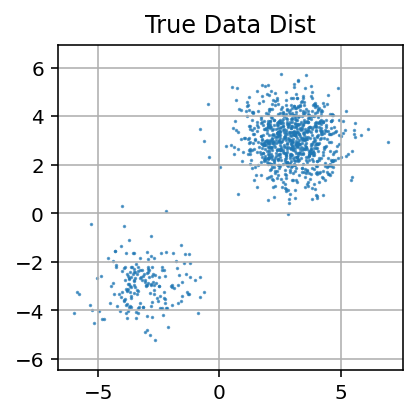

In [95]:
class Config:
    def __init__(self):
        self.dataset = "UnbalancedGaussian2D"
        self.epochs = 300
        self.size = 200000 #data set size
        self.lr : float  = 3e-4
        self.lr_warmup = 0
        self.beta1 = 0.9 #beta1 for Adam optimizer
        self.beta2 = 0.999 #beta2 for Adam optimizer
        self.batch_size = 1024
        self.num_batches = self.size // self.batch_size
        self.timesteps = 20 #diffusion timesteps

        self.beta_schedule = "linear"
        self.beta_start = 0.001 #noise level start
        self.beta_end = 0.999 #noise level end

        self.model_mean_type = "eps"
        self.model_var_type = "fixed-large"
        self.loss_type = "rssm"
        self.sampling_dist = "uniform" #"gaussian"
        self.mid_features = 128

        self.grad_norm = 0
        self.generation = 1
        self.num_sample_images =  10000
        self.num_temporal_layers = 2

        self.seed = 7777

        self.max_eval_count = 2000
        self.eval_batch_size = 1000
        self.eval_intv = 10
        self.chkpt_intv=100
        ### the 'mode' related arguments are only used for the 1D gaussian example ###
        self.modes = [1,2,3]
        self.num_modes = 3
        
        self.in_features = 1 if "1d" in self.dataset else 2

        self.exp_no = 1


        self.store_name = "_".join([
            self.dataset, str(self.size), f"{self.loss_type}", f"{self.sampling_dist}", f"{self.exp_no}"
        ])
        chkpt_dir = f"{os.getcwd()}/chkpts";os.makedirs(chkpt_dir, exist_ok=True)
        self.chkpt_dir = f"{chkpt_dir}/{self.store_name}";os.makedirs(self.chkpt_dir, exist_ok=True)
        image_dir = f"{os.getcwd()}/images";os.makedirs(image_dir, exist_ok=True)
        self.image_dir = f"{image_dir}/{self.dataset}/";os.makedirs(self.image_dir, exist_ok=True)
        self.image_dir = f"{self.image_dir}/{self.store_name}";os.makedirs(self.image_dir, exist_ok=True)
        
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')



    def _prepare_all(self):
        seed_all(self.seed)
        self.trainloader = DataStreamer(
            dataset=self.dataset,
            batch_size=self.batch_size,
            num_batches=self.num_batches,
            modes=self.modes
        )
        np.save(f"{self.chkpt_dir}/real_datatset.npy", self.trainloader.dataset.data)
        xlim, ylim = infer_range(self.trainloader.dataset)
        self.value_range = (xlim, ylim)
        self.betas = get_beta_schedule(
            self.beta_schedule,
            beta_start=self.beta_start,
            beta_end=self.beta_end,
            timesteps=self.timesteps
        )
        
        self.diffusion = GaussianDiffusion(
            betas=self.betas,
            model_mean_type=self.model_mean_type,
            model_var_type=self.model_var_type,
            loss_type=self.loss_type,
            sampling_dist=self.sampling_dist
        )

        self.model = Decoder(
            in_features=self.in_features,
            mid_features=self.mid_features,
            num_temporal_layers=self.num_temporal_layers
        )
        self.model.to(self.device)

        self.optimizer = Adam(self.model.parameters(),
                              lr=self.lr,
                              betas=(self.beta1, self.beta2))

        self.scheduler = None

        self.true_data = iter(self.trainloader)
        self.shape = tuple(next(iter(self.trainloader)).shape[1:])
        print(f"Shape of data: {self.shape}")
        print(f"Length of trainloader: {len(self.trainloader)}")
        self.evaluator = Evaluator(
            true_data=np.concatenate([
                next(self.true_data) for _ in range(self.max_eval_count // self.eval_batch_size)
            ]), eval_batch_size=self.eval_batch_size, max_eval_count=self.max_eval_count, value_range=self.value_range
        )

    def _visualize_real_train_data(self):
        plt.figure(figsize=(3,3))
        plt.scatter(*np.hsplit(next(iter(self.trainloader))[:2000], 2), s=0.5, alpha=0.7)
        plt.title("True Data Dist")
        plt.grid(True)
        plt.axis("equal")
        plt.tight_layout()




CONFIG=Config()
CONFIG._prepare_all()
diffusion_obj=CONFIG.diffusion
model_obj=CONFIG.model
evaluator_obj=CONFIG.evaluator
stats_obj = RunningStatistics(loss=None)
optimizer=CONFIG.optimizer
scheduler=DummyScheduler() if CONFIG.scheduler is None else CONFIG.scheduler
trainloader=CONFIG.trainloader
betas=CONFIG.betas

CONFIG._visualize_real_train_data()


### Training Loop

In [ ]:
class VarScheduler(object):
    def __init__(self, betas):
        self.betas = betas

        self.alphas = 1. - self.betas
        self.alphas_bar = torch.cumprod(self.alphas, dim=0)
        self.alphas_bar_prev = torch.cat([
            torch.as_tensor([1.,], dtype=torch.float64), self.alphas_bar[:-1]
        ])
        
        #q(x_t | x_0)
        self.sqrt_alphas_bar = torch.sqrt(self.alphas_bar)
        self.sqrt_one_minus_alphas_bar = torch.sqrt(1. - self.alphas_bar)

        #q(x_{t-1} | x_t, x_0)
        self.sqrt_alphas_bar_prev = torch.sqrt(self.alphas_bar_prev)
        self.sqrt_recip_alphas_bar = torch.sqrt(1. / self.alphas_bar)
        self.sqrt_recip_m1_alphas_bar = torch.sqrt(1. / self.alphas_bar - 1.) #xt, noise에서 x0 구할 때
        
        #x_{t-1}를 x_t와 noise z_t로부터 구할 때
        self.posterior_var = self.betas * (1. - self.alphas_bar_prev) / (1. - self.alphas_bar) 
        self.posterior_logvar_clipped = torch.log(
            torch.cat([self.posterior_var[[1]], self.posterior_var[1:]])
        )
        self.posterior_mean_coef1 = self.betas * self.sqrt_alphas_bar_prev / (1. - self.alphas_bar)
        self.posterior_mean_coef2 = torch.sqrt(self.alphas) * (1. - self.alphas_bar_prev) / (1. - self.alphas_bar)

        if CONFIG.model_var_type == 'fixed-large':
            self.fixed_model_var = self.betas
            self.fixed_model_logvar = torch.log(
                torch.cat([self.posterior_var[[1]], self.betas[1:]])
            )
        elif CONFIG.model_var_type == 'fixed-small':
            self.fixed_model_var = self.posterior_var
            self.fixed_model_logvar = self.posterior_logvar_clipped

var_scheduler_obj = VarScheduler(betas=CONFIG.betas)

In [98]:
def _extract(
        arr, t, x,
        dtype=torch.float32, device=torch.device("cpu"), ndim=4):
    if x is not None:
        dtype = x.dtype
        device = x.device
        ndim = x.ndim
    out = torch.as_tensor(arr, dtype=dtype, device=device).gather(0, t)
    return out.reshape((-1, ) + (1, ) * (ndim - 1))

# def _rssm_loss(denoise_fn, x_0, t, vs_obj, noise=None):
#     """
#     :parma denoise_fn: mostly the noise prediction network
#     :param x_0: data sampled from the real distribution dataset
#     :param t: time step
#     """
#     if noise is None:
#         noise = torch.randn_like(x_0)
#     x_t = _q_sample(x_0=x_0, t=t, noise=noise, vs_obj=vs_obj)

def _pred_x_0_from_mean(x_t, mean, t):
    coef1 = _extract(var_scheduler_obj.posterior_mean_coef1, t, x_t)
    coef2 = _extract(var_scheduler_obj.posterior_mean_coef2, t, x_t)
    pred_x_0 = mean / coef1 - coef2 / coef1 * x_t

    return pred_x_0

def _pred_x_0_from_eps(x_t, eps, t):
    coef1 = _extract(var_scheduler_obj.sqrt_recip_alphas_bar, t, x_t)
    coef2 = _extract(var_scheduler_obj.sqrt_recip_m1_alphas_bar, t, x_t)
    pred_x_0 = coef1 * x_t - coef2 * eps

    return pred_x_0

def _q_posterior_mean_var(x_0, x_t, t):
    """q(x_{t-1} } x_t, x_0)"""
    mean_coef1 = _extract(var_scheduler_obj.posterior_mean_coef1, t, x_0)
    mean_coef2 = _extract(var_scheduler_obj.posterior_mean_coef2, t, x_0)
    mean = mean_coef1 * x_0 + mean_coef2 * x_t
    var = _extract(var_scheduler_obj.posterior_var, t, x_0)
    logvar = _extract(var_scheduler_obj.posterior_logvar_clipped, t, x_0)

    return mean, var, logvar

def _p_mean_var(denoise_fn, x_t, t, clip_denoised:bool, return_pred:bool):
    B, D = x_t.shape
    out = denoise_fn(x_t, t) #model prediction

    if CONFIG.model_var_type == 'learned':
        out, model_logvar = out.chunk(2, dim=1)
        model_var = torch.exp(model_logvar)
    elif CONFIG.model_var_type in ['fixed-large', 'fixed-small']:
        model_var = _extract(var_scheduler_obj.fixed_model_var, t, x_t)
        model_logvar = _extract(var_scheduler_obj.fixed_model_logvar, t, x_t)
    else:
        raise NotImplementedError(CONFIG.model_var_type)

    _clip = lambda x : x 
    if CONFIG.model_mean_type == "eps":
        pred_x_0 = _clip(_pred_x_0_from_eps(x_t=x_t, eps=out, t=t))
        model_mean, _, _ = _q_posterior_mean_var(x_0=pred_x_0, x_t=x_t, t=t)
    elif CONFIG.model_mean_type == 'x_0':
        pred_x_0 = _clip(out)
        model_mean, _, _ = _q_posterior_mean_var(x_0=pred_x_0, x_t=x_t, t=t)
    elif CONFIG.model_mean_type == 'mean':
        pred_x_0 = _clip(_pred_x_0_from_mean(x_t=x_t, mean=out, t=t))
        model_mean = out
    else:
        raise NotImplementedError(CONFIG.model_mean_type)
    
    
    if return_pred:
        return model_mean, model_var, model_logvar, pred_x_0
    else:
        return model_mean, model_var, model_logvar

def _p_sample_single_step(denoise_fn, x_t, t, clip_denoised:bool=True,
                          return_pred:bool=False, generator=None):
    """input: x_t, t       output: x_{t-1}"""
    model_mean, model_var, model_logvar, pred_x_0 = _p_mean_var(
        denoise_fn=denoise_fn,
        x_t=x_t,
        t=t,
        clip_denoised=clip_denoised,
        return_pred=True
    )
    noise = torch.empty_like(x_t).normal_(generator=generator)
    nonzero_mask = (t > 0).reshape((-1, ) + (1, ) * (x_t.ndim - 1)).to(x_t)
    sample = model_mean + nonzero_mask * torch.exp(0.5 * model_logvar) * noise

    return (sample, pred_x_0) if return_pred else sample

@torch.inference_mode()
def _p_sample(denoise_fn, shape=None, noise=None):
    B = (shape or noise.shape)[0]
    t = torch.empty((B,), dtype=torch.int64, device=CONFIG.device)
    rng = None
    rng = torch.Generator(CONFIG.device).manual_seed(CONFIG.seed)
    if noise is None:
        x_t = torch.empty(shape, device=CONFIG.device).normal_(generator=rng)
    else:
        x_t = noise.to(CONFIG.device)
    
    for ti in range(CONFIG.timesteps-1, -1, -1):
        t.fill_(ti)
        x_t = _p_sample_single_step(denoise_fn, x_t, t, generator=rng)
    x_0_sampled = x_t
    return x_0_sampled

def _q_sample(x_0, t, noise=None):
    """generates x_t from x_0 (forward diffusion process)"""
    if noise is None:
        noise = torch.randn_like(x_0)
    coef1 = _extract(var_scheduler_obj.sqrt_alphas_bar, t, x_0)
    coef2 = _extract(var_scheduler_obj.sqrt_one_minus_alphas_bar, t, x_0)

    x_t = coef1 * x_0 + coef2 * noise

    return x_t

def _reverse_sample(x_t, t, noise=None):
    if noise is None:
        noise = torch.randn_like(x_t)
    coef1 = _extract(var_scheduler_obj.sqrt_recip_alphas_bar, t, x_t)
    coef2 = _extract(var_scheduler_obj.sqrt_recip_m1_alphas_bar, t, x_t)

    x_0 = coef1 * x_t - coef2 * noise
    
    return x_0

def _sample_fn(n):
    shape = (n,) + CONFIG.shape
    sample = _p_sample(denoise_fn=model_obj,
                       shape=shape,
                       noise=None)
    return sample.cpu().numpy()

In [99]:
train_loop = tqdm(range(0, CONFIG.epochs))
var_scheduler_obj = VarScheduler(CONFIG.betas)

for cur_epoch in train_loop:
    stats_obj.reset()
    model_obj.train()

    for i, x in enumerate(trainloader):
        """single training step"""
        x = x.to(CONFIG.device) #x_0
        B = x.shape[0] #batch size
        """sample random timesteps"""
        T = diffusion_obj.timesteps
        t = torch.randint(T, size=(B,), dtype=torch.int64, device=CONFIG.device)
        if len(x.shape) == 1:
            x = x.unsqueeze(1)
        noise = torch.randn_like(x)
        """get x_t from x_0 with scheduler and sampled timestep"""
        x_t = _q_sample(x_0=x, t=t,  noise=noise)
        """calculate loss"""
        if CONFIG.loss_type == 'rssm':
            noise_2 = torch.randn_like(x)
            if CONFIG.sampling_dist == 'uniform':
                sample_xt = torch.randn_like(x) * 12 - 6
            elif CONFIG.sampling_dist == 'gaussian':
                sample_xt = torch.randn_like(x) * 2
            elif CONFIG.sampling_dist == 'pt':
                sample_xt = x_t.clone()
            else:
                raise NotImplementedError
            
            tilde_x_0 = _reverse_sample(sample_xt, t, noise=noise_2)
            energy = 100 * \
                (0.8 * torch.exp(-torch.linalg.norm(tilde_x_0 - 3 * torch.ones_like(x_t), axis=1) ** 2 / 2) + \
                 0.2 * torch.exp(-torch.linalg.norm(tilde_x_0 + 3 * torch.ones_like(x_t), axis=1) ** 2 / 2))
            model_out = model_obj(sample_xt, t)
            losses = energy * flat_mean((noise_2 - model_out).pow(2))
            model_out_norm = torch.linalg.norm(model_out, axis=1).mean().item()
        else:
            raise NotImplementedError
        """update model params"""
        loss = losses.mean()
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()
        stats_obj.update(B, loss=loss.item() * B)
        train_loop.set_postfix({'loss': loss.item()})
        """evaluate"""
        if i == len(trainloader)-1:
            eval_results = dict()
            if (cur_epoch + 1) % CONFIG.eval_intv == 0:
                model_obj.eval()
                eval_results = evaluator_obj.eval(sample_fn=_sample_fn)
            x_gen = eval_results.pop("x_gen", None)
            if x_gen is not None:
                save_scatterplot(
                    os.path.join(CONFIG.image_dir, f"{cur_epoch+1}.jpg"), x_gen,
                    xlim=CONFIG.value_range[0],
                    ylim=CONFIG.value_range[1]
                )
            results = dict()
            results.update(stats_obj.extract())
            results.update(eval_results)

    scheduler.step()
    if not (cur_epoch+1)%CONFIG.chkpt_intv and CONFIG.chkpt_dir:
        chkpt = []
        for k, v in model_obj.state_dict().items():
            chkpt.append((k, v))
        for k, v in optimizer.state_dict().items():
            chkpt.append((k, v))
        # if scheduler is not None:
        if isinstance(scheduler, DummyScheduler) == False:
            for k, v in scheduler.state_dict().items():
                chkpt.append((k, v))
        torch.save(dict(chkpt), f"{CONFIG.chkpt_dir}/{cur_epoch+1}.ckpt")
model_obj.eval()
eval_results = evaluator_obj.eval(sample_fn=_sample_fn)
x_gen = eval_results.pop("x_gen", None)

np.save(f"{CONFIG.chkpt_dir}/gen_dataset.npy", x_gen)
print(x_gen.shape)
plt.figure(figsize=(3, 3))
plt.scatter(*np.hsplit(x_gen, 2), s=0.5, alpha=0.7)
plt.title(f"RSSM w/ {CONFIG.sampling_dist} sample")
plt.xlim([-6, 6]);plt.ylim([-6, 6])
plt.grid(True)
plt.xticks(np.array([-6, -3, 0, 3, 6]));plt.yticks(np.array([-6, -3, 0, 3, 6]))
plt.savefig(f"{CONFIG.chkpt_dir}/generated.pdf")
plt.close()


100%|██████████| 300/300 [04:50<00:00,  1.03it/s, loss=0.0833] 


(2000, 2)


Text(0.5, 1.0, '$ x_{denoised} \\ [-6,6] \\ limit $')

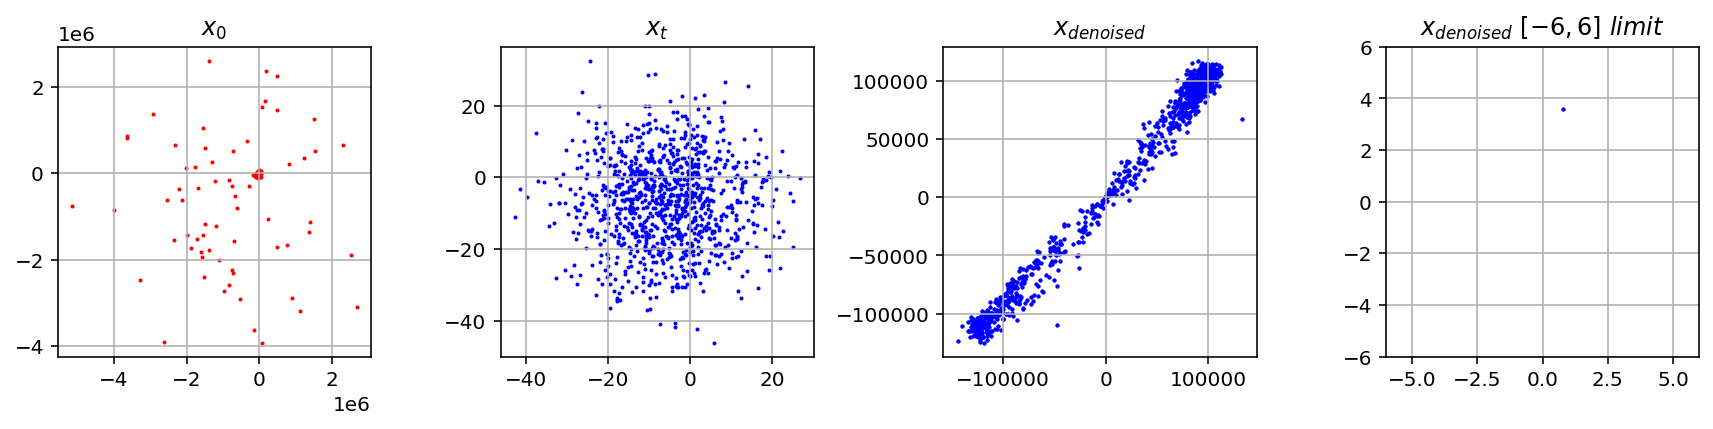

In [100]:
fig, ax = plt.subplots(1, 4, figsize=(12, 3))
ax[0].scatter(tilde_x_0.cpu()[:, 0], tilde_x_0.cpu()[:, 1], s=1, c='r')
ax[1].scatter(sample_xt.cpu()[:, 0], sample_xt.cpu()[:, 1], s=1, c='b')
ax[2].scatter(x_gen[:, 0], x_gen[:, 1], s=1, c='b')
ax[3].scatter(x_gen[:, 0], x_gen[:, 1], s=1, c='b')

plt.tight_layout()
for i in range(4):
    ax[i].grid(True)
ax[0].set_title(r'$ x_{0} $')
ax[1].set_title(r'$ x_{t} $')
ax[2].set_title(r'$ x_{denoised} $')
ax[3].set_xlim([-6, 6]);ax[3].set_ylim([-6, 6])
ax[3].set_title(r'$ x_{denoised} \ [-6,6] \ limit $')
